In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.stats import poisson, norm

from StockPathSimulation import StockPathSimulation
from StrategySimulation import StrategySimulation

### Simulation of Stock Paths

In [3]:
t = 1
nSims = 100
nSteps = 255
sps = StockPathSimulation(expirationTime = t,
                          numOfSims = nSims,
                          numOfSteps = nSteps)

Let $W(t)$ denote the Brownian motion process. Then, for any partition $0 = t_0 < t_1 < \dotsb < t_n$, the increments
\begin{equation*}
W(t_1) = W(t_1) - W(t_0), \dotsc, W(t_n) - W(t_{n-1})
\end{equation*}
are independent and each increment is normally distributed with
\begin{equation*}
\mathbb{E}(W(t_{i+1}) - W(t_i)) = 0 \hspace{10pt} \text{ and } \hspace{10pt}  Var(W(t_{i+1}) - W(t_i))= t_{i+1} - t_i.
\end{equation*}

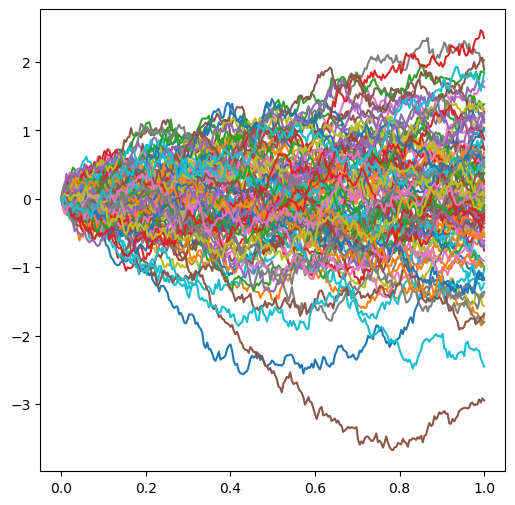

In [5]:
process = sps.simBrownianMotionProcess()

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

sps.plotSimulation(process,ax)

plt.show()

The geometric Brownian motion with mean rate of return $\alpha$ and volatility $\sigma$ is given by
\begin{equation*}
S(t) = S(0) \exp \left ( \sigma W(t) + (\alpha - \frac{1}{2}\sigma^2) t\right )
\end{equation*}

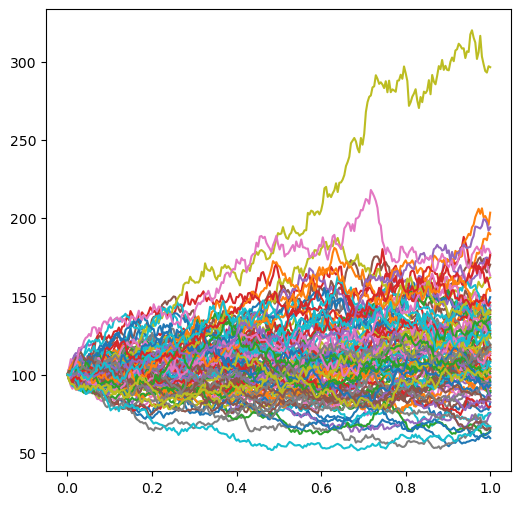

In [7]:
process = sps.simGeomBrownianMotion(meanRateOfReturn = 0.2,
                                   volatility = 0.3,
                                   initialPrice = 100.0)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

sps.plotSimulation(process,ax)

plt.show()

Let $N(t)$ denote the Poisson process with intensity $\lambda$. By Theorem 11.2.3, for any partition $0 = t_0 < t_1 < \dotsb < t_n$, the increments
\begin{equation*}
N(t_1) - N(t_0), \dotsc, N(t_n) - N(t_{n-1})
\end{equation*}
are independent and
\begin{equation*}
P(\{N(t_{j+1}) - N(t_j) = k\}) = \frac{\lambda^k(t_{j+1}-t_j)^k}{k!} e^{-\lambda(t_{j+1} - t_j)}.
\end{equation*}
We will use this property to simulate the Poisson process.

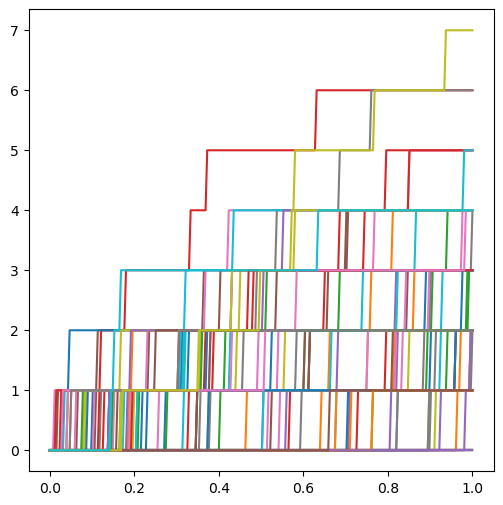

In [9]:
process = sps.simPoissonProcess(intensity= 2)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

sps.plotSimulation(process, ax)

plt.show()

Let $N(t)$ be a Poisson process with intensity $\lambda$ and let $Y_1, Y_2, \dotsc$ be a sequence of independent and identically distributed random variables with mean $\beta = \mathbb{E}(Y_i)$. We define the compound Poisson process by
\begin{equation*}
Q(t) = \sum_{i=1}^{N(t)} Y_i.
\end{equation*}


Now suppose that, for each $i$, $Y_i$ takes on finitely many values $y_1, \dotsc, y_M$ and let $p(y_m) = P(\{Y_i = y_m\})$. By Corollary 11.3.4 (Shreve),
\begin{equation*}
N(t) = \sum_{m=1}^M N_m(t) \hspace{10pt} \text{ and } \hspace{10pt} Q(t) = \sum_{m=1}^M y_m N_m(t)
\end{equation*}
where $N_1, \dotsc, N_m$ are independent Poisson processes and each $N_m$ has intensity $\lambda p(y_m)$.

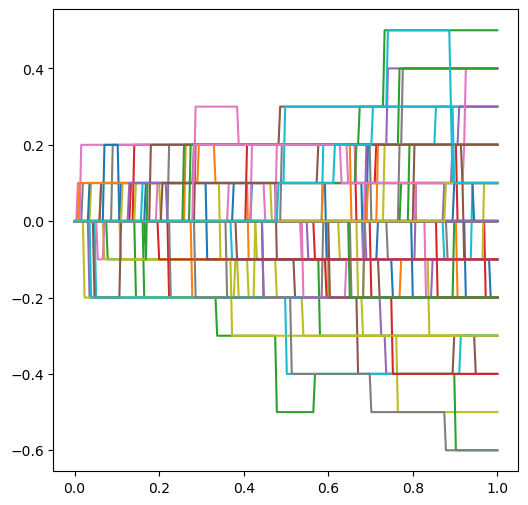

In [11]:
process = sps.simCompoundPoissonProcess(intensity = 2,
                                        jumps = [-0.2,-0.1,0.1,0.2],
                                        jumpProbabilities = [0.25,0.25,0.25,0.25])

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

sps.plotSimulation(process, ax)

plt.show()

We simulate an asset driven by a Poisson Process. The asset price
\begin{equation*}
S(t) = S(0) e^{(\alpha - \lambda \sigma)t} (\sigma+1)^{N(t)}
\end{equation*}
is the solution to the stochastic differential equation
\begin{equation*}
d S(t) = \alpha S(t) \,dt + \sigma S(t-) \,dM(t),
\end{equation*}
N(t) is a Poisson process with intensity $\lambda > 0$ and $M(t) = N(t) - \lambda t$.

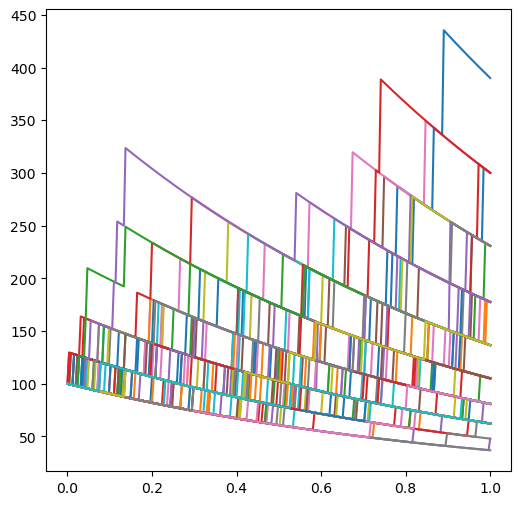

In [13]:
process = sps.assetModel1(meanRateOfReturn = 0.2,
                          volatility = 0.3,
                          intensity = 4.0,
                          initialPrice = 100.0)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

sps.plotSimulation(process, ax)

plt.show()

We simulate an asset using the jump diffusion model. Let $\lambda_1, \dotsc, \lambda_M$ be positive numbers and let $-1 < y_1 < \dotsb < y_M$ be nonzero numbers. Let $W(t)$ be a Brownian motion process and $Q(t) = \sum_{i=1}^{M} y_m N_m(t)$ be a compound Poisson process with intensity $\lambda = \sum_{m=1}^M \lambda_m$, where $N_1(t), \dotsc, N_m(t)$ are independent Poisson processes with intensities $\lambda_1, \dotsc, \lambda_m$. Set
\begin{equation*}
\beta = \frac{1}{\lambda} \sum_{m=1}^M \lambda_m y_m = \sum_{m=1}^M P(\{Y_i = y_m\}) y_m.
\end{equation*}
The stock price is modeled by the stochastic differential equation
\begin{equation*}
dS(t) = (\alpha - \beta \lambda)S(t) \, dt + \sigma S(t) \, dW(t) + S(t-)\, dQ(t).
\end{equation*}
By Theorem 11.7.3 (Shreve), the solution to this stochastic differential equation is
\begin{equation*}
S(t)=S(0)\text{exp}\biggl\{\sigma W(t) + \left( \alpha - \beta\lambda -\frac{1}{2}\sigma^2\right) t \biggr\} \prod_{i=1}^{N(t)}(Y_i+1).
\end{equation*}

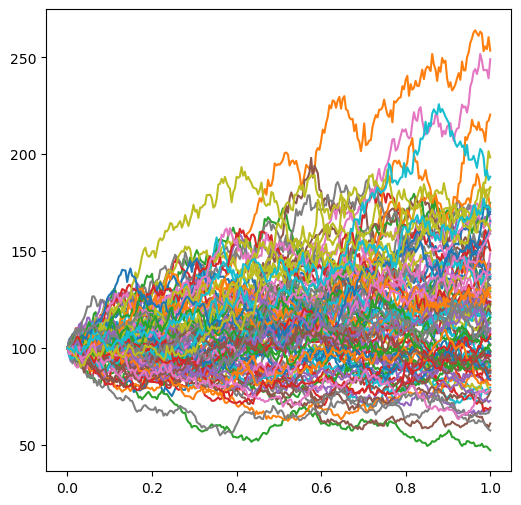

In [15]:
process = sps.assetModel2(meanRateOfReturn = 0.2,
                          volatility = 0.3,
                          intensity = 2.0,
                          jumps = [-0.02,-0.01,0.01,0.02],
                          jumpProbabilities = [0.25,0.25,0.25,0.25],
                          initialPrice = 100.0)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

sps.plotSimulation(process, ax)

plt.show()

### Call Option Price Models and Hedging Strategies

In [17]:
interestRate = 0.01

ss = StrategySimulation(expirationTime = t,
                        numOfSims = nSims,
                        numOfSteps = nSteps,
                        interestRate = interestRate)

We consider a call option of an underlying stock with strike price $K$ and expiration time $T$.
Let $c(t,x)$ denote the value of the call option at time $t$ when the price of the underlying stock is $x$ at time $t$.
For a stock modeled by the geometric Brownian motion, the call option price is $c(t,x) = \kappa(T-t,x)$ where $\kappa(\tau,x)$ is
\begin{equation*}
\kappa(\tau,x) = \frac{1}{\sqrt{2\pi}} \int_{-\infty}^\infty e^{-r\tau} \left ( x e^{-\sigma \sqrt{\tau}y + (r-\frac{1}{2}\sigma^2)\tau} - K \right )^+ e^{-\frac{1}{2}y^2} \,dy.
\end{equation*}
Set
\begin{equation*}
d(\tau,x) = \frac{\log(x/K) + (r-\frac{1}{2}\sigma^2)\tau}{\sigma \sqrt{\tau}}.
\end{equation*}
Then, (see Exercise 4.9)
\begin{equation*}
\kappa (\tau,x) = x\frac{1}{\sqrt{2\pi}} \int_{-\infty}^{d(\tau,x) + \sigma \sqrt{\tau}}  e^{-\frac{1}{2}y^2}  \,dy - e^{-r\tau}K\frac{1}{\sqrt{2\pi}} \int_{-\infty}^{d(\tau,x)}  e^{-\frac{1}{2}y^2}  \,dy.
\end{equation*}

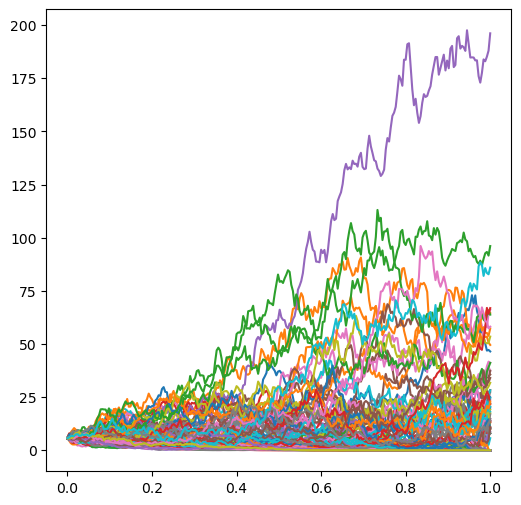

In [19]:
process = sps.simGeomBrownianMotion(meanRateOfReturn = 0.2,
                                    volatility = 0.3,
                                    initialPrice = 100.0)

optionPrice = ss.kappa(process, np.array([120]), 0.3)


fig, ax = plt.subplots(1, 1, figsize=(6, 6))

ss.plotSimulation(optionPrice, ax)

plt.show()


A short option hedging porfolio starts wtih an initial capital $X(0) = c(0,S(0))$ and invests in the stock and money market account so that 
\begin{equation*}
X(t) = c(t,S(t))
\end{equation*}
for all $t \in [0,T]$. To construct a hedging portfolio, we follow the delta-hedging rule and hold $\Delta(t)$ shares of the underlying stock at time $t$, where
\begin{equation*}
\Delta(t) = \kappa_x(\tau,x) = \frac{1}{\sqrt{2\pi}} \int_{-\infty}^{d(\tau,x) + \sigma \sqrt{\tau}}  e^{-\frac{1}{2}y^2}  \,dy.
\end{equation*}
Let $0 = t_0 < \dotsb < t_n$ be a sequence of moments in time. We calculate the portfolio value $X(t_i)$ at time $t_i$ using the formula 
\begin{equation*}
X(t_i) = \Gamma(t_i,S(t_i)) S(t_i) + (X(0) - \Gamma(0,S(0))S(0))e^{rt_i} + \sum_{j=1}^i (\Gamma (t_{j-1}, S(t_{j-1})) - \Gamma (t_j, S(t_j)))e^{r(t_i-t_j)} S(t_j).
\end{equation*}


In [21]:
discountedOptionPrice = ss.discountPrices(optionPrice)
vals = ss.calculateDiscountedPortfolioValues(optionPrice[:,0],process,ss.delta(process,np.array([120]),0.3))

diff = (vals - discountedOptionPrice)
a, b, l = diff.shape

print(f'root mean square error is {np.sqrt(np.sum(diff * diff)/(a*b*l))}')
print(f'root mean square error at expiration time is {np.sqrt(np.sum(diff[:,-1] * diff[:,-1])/(a*l))}')


root mean square error is 0.42928627532405955
root mean square error at expiration time is 0.6304078091045741


Next, we consider a call option of an underlying stock modeled by
\begin{equation*}
S(t) = S(0) e^{(\alpha - \lambda \sigma)t} (\sigma+1)^{N(t)},
\end{equation*}
where N(t) is a Poisson process with intensity $\lambda > 0$. Set
\begin{equation*}
\tilde{\lambda} = \lambda - \frac{(\alpha -r)}{\sigma}.
\end{equation*}
By Example 11.6.3 (Shreve), we must have $\tilde{\lambda} > 0$ in order to rule out arbitrage.
Then, the call option price is given by
\begin{equation*}
\begin{split}
c(t,x) & = \tilde{\mathbb{E}} \left ( e^{-r(T-t)} \left ( x e^{(r-\tilde{\lambda}\sigma)(T-t)} (\sigma+1)^{N(T) - N(t)} - K\right )^+ \right ) \\
& = \sum_{j=0}^\infty \left ( xe^{-\tilde{\lambda}\sigma(T-t)}(\sigma+1)^j - K e^{-r(T-t)}\right )^+ \frac{\tilde{\lambda}^j (T-t)^j}{j!} e^{-\tilde{\lambda}(T-t)}
\end{split}
\end{equation*}



Note that each summand is bounded from above by
\begin{equation*}
xe^{-\tilde{\lambda}\sigma(T-t)}(\sigma+1)^j \frac{\tilde{\lambda}^j (T-t)^j}{j!} e^{-\tilde{\lambda}(T-t)} = x \frac{\tilde{\lambda}^j (\sigma + 1)^j (T-t)^j}{j!} e^{-\tilde{\lambda}(\sigma + 1)(T-t)}
\end{equation*}
So, we can estimate $c(t,x)$ up to an error of $\epsilon$ as long as we include the first $j_{max}$ terms where $j_{max}$ is a positive integer satisfying
\begin{equation*}
x \sum_{j=j_{max}+1}^\infty \frac{\tilde{\lambda}^j (\sigma + 1)^j (T-t)^j}{j!} e^{-\tilde{\lambda}(\sigma + 1)(T-t)} < \epsilon.
\end{equation*}


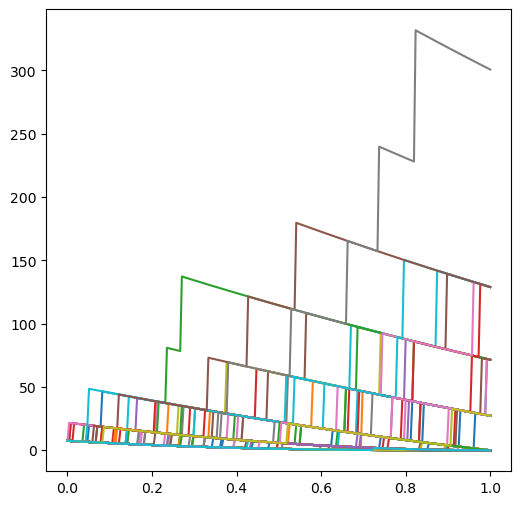

In [23]:
meanRateOfReturn = 0.2
volatility = 0.3
intensity = 2.0
initialPrice = 100.0
K = np.array([120])
error = 1e-6

process = sps.assetModel1(meanRateOfReturn = meanRateOfReturn,
                          volatility = volatility,
                          intensity = intensity,
                          initialPrice = initialPrice)

ltild = intensity - ((meanRateOfReturn - interestRate) / volatility)

optionPrice = ss.poissonCallPrice(process, K, volatility, ltild, error)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

ss.plotSimulation(optionPrice, ax)

plt.show()

To construct a hedgine porfolio, we hold $\Gamma(t)$ shares of the underlying stock at time $t$, where
\begin{equation*}
\Gamma(t) = \frac{c(t,(\sigma+1)S(t)) - c(t,S(t))}{\sigma S(t)}.
\end{equation*}

In [25]:
discountedOptionPrice = ss.discountPrices(optionPrice)
vals = ss.calculateDiscountedPortfolioValues(optionPrice[:,0],process,ss.gamma1(process,K, volatility, ltild, error))

diff = (vals - discountedOptionPrice)
a, b, l = diff.shape

print(f'root mean square error is {np.sqrt(np.sum(diff * diff)/(a*b*l))}')
print(f'root mean square error at expiration time is {np.sqrt(np.sum(diff[:,-1] * diff[:,-1])/(a*l))}')

root mean square error is 1.1042971068229648
root mean square error at expiration time is 1.9993069176510387


Finally, we consider a call option of an underlying stock modeled by
\begin{equation*}
S(t)=S(0)\text{exp}\biggl\{\sigma W(t) + \left( \alpha - \beta\lambda -\frac{1}{2}\sigma^2\right) t \biggr\} \prod_{i=1}^{N(t)}(Y_i+1).
\end{equation*}
where $N(t)$ is a Poisson process with intensity $\lambda$ and $Y_1, Y_2, \dotsc$ form a sequence of independent and identically distributed random variables with mean $\beta = \mathbb{E}(Y_i)$. We further assume that, for each $i$, $Y_i$ takes on finitely many values $y_1, \dotsc, y_M$ and write $p(y_m) = P(\{Y_i = y_m\})$.


Let $\theta$ and let $\tilde{\lambda}_1, \dotsc, \tilde{\lambda}_M > 0$ be constants such that
\begin{equation*}
\alpha - r = \sigma \theta + \sum_{m=1}^M (\lambda_m - \tilde{\lambda}_m) y_m.
\end{equation*}
Then, there exists a probability measure $\tilde{P}$ such that (see page 515, Section 11.7.2 of Shreve)

1) the process $\tilde{W}(t) = W(t) + \theta t$ is a Brownian motion,

2) the process $N(t) = \sum_{m=1}^M N_m(t)$ is Poisson with intensity $\tilde{\lambda} := \sum_{m=1}^N \tilde{\lambda}_m$,

3) $N_1, \dotsc, N_M$ are independent Poisson processes,

4) each $N_m$ has intensity $\tilde{\lambda}_m$, and

5) the jump-size variables $Y_1, Y_2, \dotsc$ are independent and identically distributed with $\tilde{P}(\{Y_i = y_m\}) = \tilde{p}(y_m)= \frac{\tilde{\lambda}_m}{\tilde{\lambda}}$.

Set
\begin{equation*}
\tilde{\beta} = \tilde{E}(Y_i) = \sum_{m=1}^M y_m \tilde{p}(y_m) = \frac{1}{\tilde{\lambda}} \sum_{m=1}^M \tilde{\lambda}_m y_m.
\end{equation*}
Then,
\begin{equation*}
S(t)=S(0)\text{exp}\biggl\{\sigma \tilde{W}(t) + \left( r - \tilde{\beta}\tilde{\lambda} -\frac{1}{2}\sigma^2\right) t \biggr\} \prod_{i=1}^{N(t)}(Y_i+1).
\end{equation*}
By Theorem 11.7.5, the risk-neutral price of a call is given by
\begin{equation*}
\begin{split}
c(t,x) & = \sum_{j=0}^\infty e^{-\tilde{\lambda} (T-t)} \frac{\tilde{\lambda}^j (T-t)^j}{j!} \tilde{\mathbb{E}} \left ( \kappa \left ( T-t, xe^{-\tilde{\beta}\tilde{\lambda}(T-t)} \prod_{i=1}^j (Y_i + 1) \right ) \right ) \\
& = \sum_{j=0}^\infty e^{-\tilde{\lambda} (T-t)} \frac{\tilde{\lambda}^j (T-t)^j}{j!} \sum_{1 \leq m_1, \dotsb, m_j \leq M} \left (  \prod_{i=1}^j \tilde{p}(y_{m_i}) \right ) \kappa \left ( T-t, xe^{-\tilde{\beta}\tilde{\lambda}(T-t)} \prod_{i=1}^j (y_{m_i} + 1) \right ) \\
& = \sum_{j=0}^\infty e^{-\tilde{\lambda} (T-t)} \frac{\tilde{\lambda}^j (T-t)^j}{j!} \sum_{k_1 + \dotsb + k_M = j}  \frac{j!}{k_1! \dotsb k_M!} \left ( \prod_{m=1}^M \tilde{p}(y_{m})^{k_m} \right )  \kappa \left ( T-t, xe^{-\tilde{\beta}\tilde{\lambda}(T-t)} \prod_{m=1}^M (1 + y_{m})^{k_m} \right ).
\end{split}
\end{equation*}

We observe that
\begin{equation*}
\begin{split}
& e^{-\tilde{\lambda} (T-t)} \frac{\tilde{\lambda}^j (T-t)^j}{j!} \sum_{1 \leq m_1, \dotsb, m_j \leq M} \left (  \prod_{i=1}^j \tilde{p}(y_{m_i}) \right ) \kappa \left ( T-t, xe^{-\tilde{\beta}\tilde{\lambda}(T-t)} \prod_{i=1}^j (y_{m_i} + 1) \right ) \\
& \leq e^{-\tilde{\lambda} (T-t)} \frac{\tilde{\lambda}^j (T-t)^j}{j!} \sum_{1 \leq m_1, \dotsb, m_j \leq M} \left (  \prod_{i=1}^j \tilde{p}(y_{m_i}) \right )  xe^{-\tilde{\beta}\tilde{\lambda}(T-t)} \prod_{i=1}^j (y_{m_i} + 1) \\
& = x e^{-\tilde{\lambda}(1 + \tilde{\beta}) (T-t)} \frac{\tilde{\lambda}^j (1+\tilde{\beta})^j (T-t)^j}{j!}
\end{split}
\end{equation*}
So, we can estimate $c(t,x)$ up to an error of $\epsilon$ as long as we include the first $j_{max}$ terms where $j_{max}$ is a positive integer satisfying
\begin{equation*}
x \sum_{j=j_{max}+1}^\infty \frac{\tilde{\lambda}^j (1 + \tilde{\beta})^j (T-t)^j}{j!} e^{-\tilde{\lambda}(1 + \tilde{\beta})(T-t)} < \epsilon.
\end{equation*}

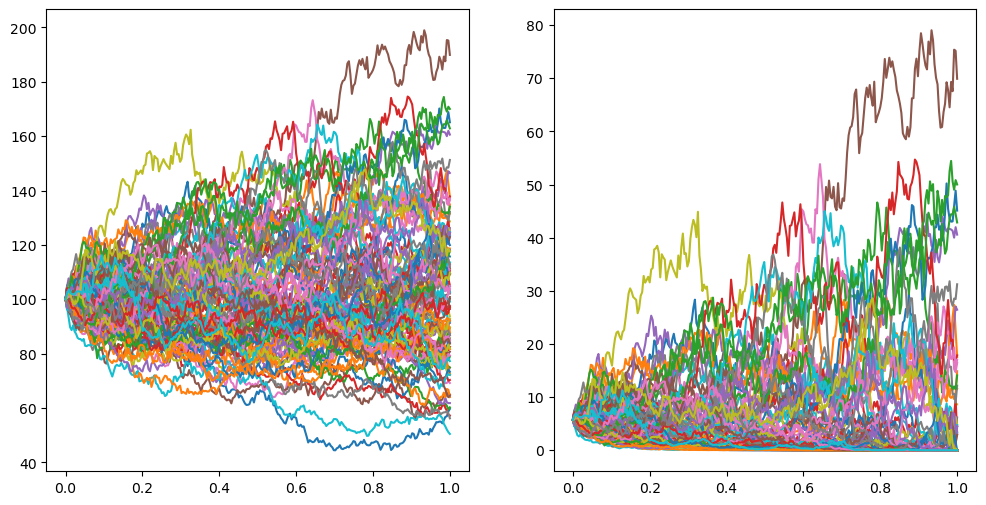

In [27]:
meanRateOfReturn = 0.2
volatility = 0.3
intensity = 2.0
jumps = [-0.01,0.01]
jumpProbabilities = [0.5,0.5]
parameters = [0.2,0.4]

initialPrice = 100.0
K = np.array([120])
error = 1e-3


process = sps.assetModel2(meanRateOfReturn = interestRate,
                            volatility = volatility,
                            intensity = np.sum(parameters),
                            jumps = jumps,
                            jumpProbabilities = np.array(parameters)/np.sum(np.array(parameters)),
                            initialPrice = initialPrice)


optionPrice = ss.jumpDiffusionCallPrice(process, K, volatility, jumps, parameters, error)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sps.plotSimulation(process,ax[0])
ss.plotSimulation(optionPrice, ax[1])


plt.show()

We observe that, for any $\tau \geq 0$ and $x > 0$,
\begin{equation*}
0 \leq  \kappa_x(\tau, x) \leq 1.
\end{equation*}
It follows that the derivative $c_x(t,x)$ is obtained from term-by-term differentiation. In other words,
\begin{equation*}
 c_x(t,x)  = = \sum_{j=0}^\infty e^{-(1 + \tilde{\beta}) \tilde{\lambda} (T-t)} \frac{\tilde{\lambda}^j (T-t)^j}{j!} \sum_{k_1 + \dotsb + k_M = j}  \frac{j!}{k_1! \dotsb k_M!} \left ( \prod_{m=1}^M \tilde{p}(y_{m})^{k_m} (1 + y_{m})^{k_m}\right )  \kappa_x \left ( T-t, xe^{-\tilde{\beta}\tilde{\lambda}(T-t)}  \prod_{m=1}^M (1 + y_{m})^{k_m}\right ).
\end{equation*}
We implement the delta-hedging strategy
\begin{equation*}
\Gamma(t) = c_x(t,S(t)).
\end{equation*}
Then, the portfolio outperforms the option between jumps while the option outperforms the portfolio at jump times.
While this strategy will not construct a hedging portfolio, the expected value of the difference between the portfolio and the option is always zero.
In other words,
\begin{equation*}
\tilde{\mathbb{E}} \left ( e^{-rt} c(t,S(t)) \right ) = \tilde{\mathbb{E}} \left ( e^{-rt} X(t) \right )
\end{equation*}
for all $0 \leq t \leq T$.

In [29]:
discountedOptionPrice = ss.discountPrices(optionPrice)
vals = ss.calculateDiscountedPortfolioValues(optionPrice[:,0],process,ss.gamma2(process,K, volatility, jumps, parameters, error))

diff = (vals - discountedOptionPrice)
a, b, l = diff.shape
expDiff = np.sum(diff, axis = 0) / a

print(f'root mean square error is {np.sqrt(np.sum(expDiff * expDiff)/(b*l))}')

root mean square error is 0.023303151873879675


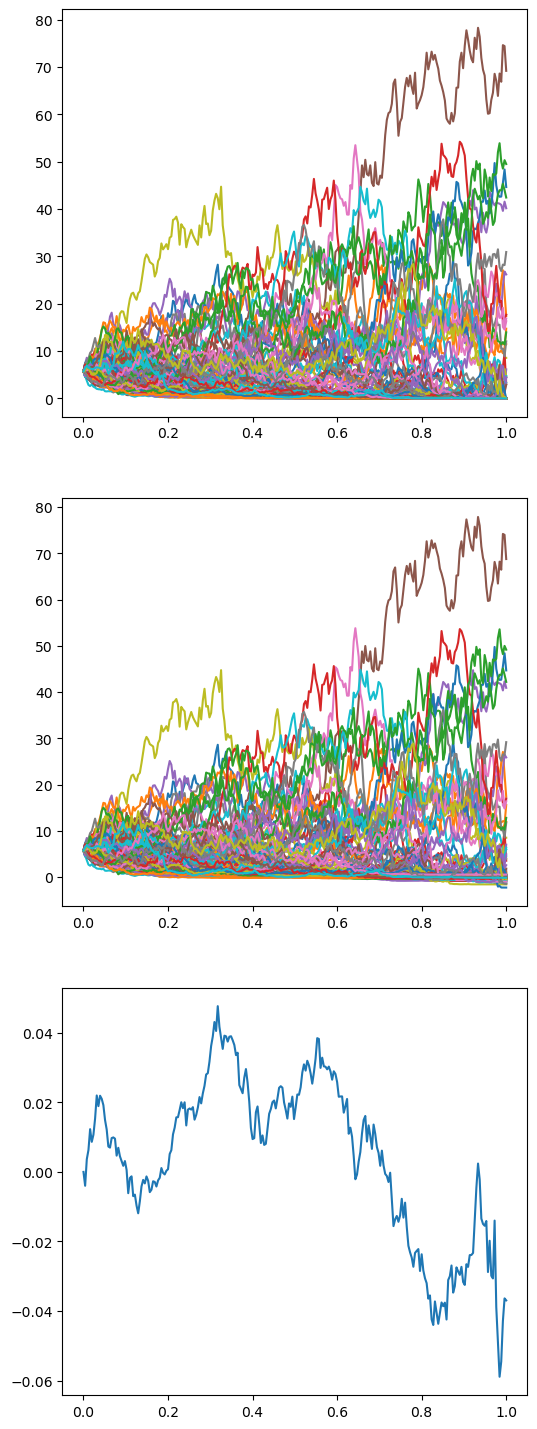

In [30]:
fig, ax = plt.subplots(3, 1, figsize=(6, 18))

sps.plotSimulation(discountedOptionPrice,ax[0])
ss.plotSimulation(vals, ax[1])
ax[2].plot(ss.times, expDiff)


plt.show()

We compute the root mean square error with a different set of parameters.

root mean square error is 0.04542714052494083


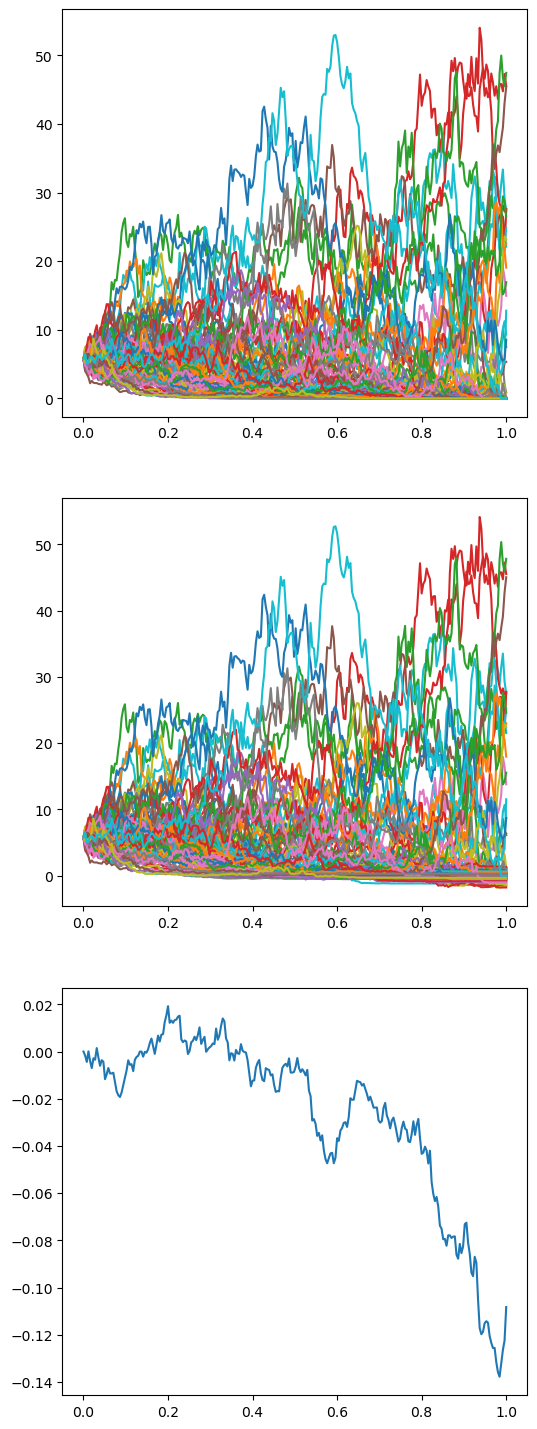

In [32]:
meanRateOfReturn = 0.2
volatility = 0.3
intensity = 2.0
jumps = [-0.01,0.01]
jumpProbabilities = [0.5,0.5]
parameters = [0.5,0.5]

initialPrice = 100.0
K = np.array([120])
error = 1e-3


process = sps.assetModel2(meanRateOfReturn = interestRate,
                            volatility = volatility,
                            intensity = np.sum(parameters),
                            jumps = jumps,
                            jumpProbabilities = np.array(parameters)/np.sum(np.array(parameters)),
                            initialPrice = initialPrice)


optionPrice = ss.jumpDiffusionCallPrice(process, K, volatility, jumps, parameters, error)


discountedOptionPrice = ss.discountPrices(optionPrice)
vals = ss.calculateDiscountedPortfolioValues(optionPrice[:,0],process,ss.gamma2(process,K, volatility, jumps, parameters, error))

diff = (vals - discountedOptionPrice)
a, b, l = diff.shape
expDiff = np.sum(diff, axis = 0) / a

print(f'root mean square error is {np.sqrt(np.sum(expDiff * expDiff)/(b*l))}')


fig, ax = plt.subplots(3, 1, figsize=(6, 18))

sps.plotSimulation(discountedOptionPrice,ax[0])
ss.plotSimulation(vals, ax[1])
ax[2].plot(ss.times, expDiff)


plt.show()